# Proyecto Final
# Técnico en Gestión de Datos para el Análisis y Visualización

# Curso: Aprendizaje Automático I

# Objetivo:
Completar los siguientes puntos que representan los pasos para implementar un sistema para aplicar regresión seleccionando la primer característica (que tenga la mayor métrica) obtenida por el método de **mutual information** para predecir el rendimiento del consumo de combustible (la columna MPG que significa Miles Per Gallon)

#Instrucciones:

Completar los pasos con código de Python que se ubican en el instrutivo.

Debes crear las sufientes/necesarias celdas para que se puede escribir el código sugerido.

Use únicamente el código que se necesita. No escriba de más!

Nótese que involucran los siguientes pasos:

1. Importar la bibliotecas
1. Extracción de los datos
1. Limpieza de datos
1. Transformación
1. Apliación del procedimiento de mutual información
1. Aplicación de la red neuronal
1. Visualización

Comparte con el profesor el enlace de Google Colab. Recuerda darle permisos de lectura usando el correo ericksc@gmail.com


## 1. Importa las bibliotecas

Use el código que se encuentra a continuación

```Python
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Para aplicar mutual information
from sklearn.feature_selection import mutual_info_regression

# Para crear la red neuronal
import tensorflow as tf
from tensorflow import keras

# Para el escalado
from sklearn.preprocessing import MinMaxScaler

# Para partir el dataset en training y testing
from sklearn.model_selection import train_test_split

# Para medir el rendimiento
from sklearn.metrics import accuracy_score
```

# 2. Extraiga la información

 Desde el archivo 'auto-mpg.csv'

 2.1 Crear un dataframe. Recuerda que tienes que definir una variable. Se sugiere el nombre de la variable: data

 2.2 Muestre los datos del dataframe usando la función .head()

# 3. Limpieza de datos

3.1. Muestre un sumario con la información de la cantidad de valores nulos por columna.
 Se  espera el siguiente resultado
```
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64
```

3.2. Remueva las filas que tengan valores nulos o 'missing data'

# 4. Transformación

4.1 Crear un dataframe de nombre ***X*** con todas las columnas excepto "MPG"

4.2 Crear un dataframe de nombre ***y*** que contenga la columna "MPG"

4.3 Separe X e y en entrenamiento (60 %), validación (20 %) y prueba (20 %) con random_state=42, antes de calcular MI o ajustar cualquier transformación. Conserve los índices de estas particiones durante todo el proyecto.


# 5. Aplicación del procedimiento de mutual information

5.1 Use únicamente X_train e y_train para estimar MI.

5.2 Marque como discretas Cylinders, Model Year y Origin; las restantes magnitudes son continuas. Si aparecen categorías de texto, aprenda su codificación solamente con entrenamiento.

5.3 Fije random_state=42 al calcular mutual_info_regression.

Obtenga una Series con las puntuaciones calculadas en entrenamiento y ordénela. El nombre y valor de la primera variable deben proceder de esa ejecución; no hay un ranking numérico obligatorio.

5.4 Crear un gráfico de barrar que muestre los valores del mutual information de cada una de las columnas. (use el procedimiento de mutual information visto en clase)

Debe verse como lo siguiente:


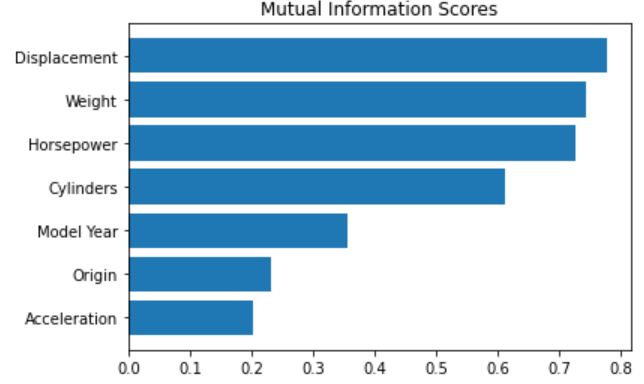


**Figura orientativa:** la imagen incrustada corresponde a un ejemplo anterior. No debe reproducir sus valores exactos; genere su gráfico con las particiones y la característica elegida en su propia ejecución.


5.5 Obtenga un gráfico de puntos 'scatter plot' que tenga en el eje "y" los valor de MPG y en eje "x" los datos de la columna que se obtuvo la mayor puntuación de mutual información.

Debe observar como lo siguiente (los nombres de los ejes fueron removidos intencionalmente para efectos de intructivo):


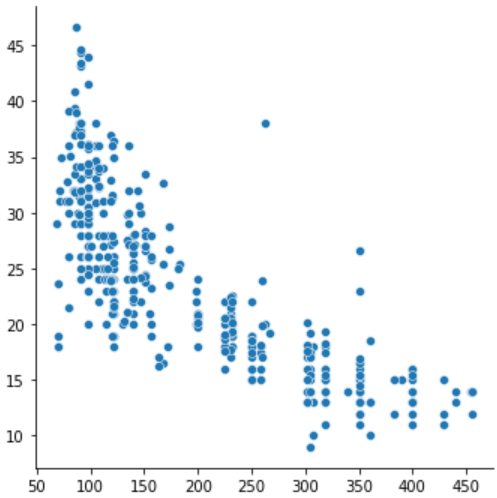

**Figura orientativa:** la imagen incrustada corresponde a un ejemplo anterior. No debe reproducir sus valores exactos; genere su gráfico con las particiones y la característica elegida en su propia ejecución.


# 6. Aplicación de red neuronal

Usando únicamente el feature que obtuvo el **mayor puntaje** en el procedimiento de mutual information.

6.1 Crear el dataframe 'feature_df' usando exclusivamente la columna que tiene el mayor puntaje de mutual information.

6.2 Crear el dataframe 'label_df' que contenga únicamente la columna 'MPG'. Esta columna la vamos usar como etiqueta de la regresión.

6.3 Reutilice las particiones del paso 4.3. En cada una seleccione la misma columna, elegida exclusivamente con la MI de entrenamiento. No vuelva a dividir los datos.

6.4 Ajuste el escalador con X_train y aplique transform a X_train, X_val y X_test. Nunca use fit o fit_transform sobre validación o prueba.

6.5 Implementar el siguiente modelo de ***red neuronal*** (nótose que se está solicitando esa red neuronal. **Debes** usarla):

```Python
# Se crea un modelo usando un red neuronal multicapa con una característica de entrada
red_modelo = keras.Sequential([
    keras.layers.Dense(units=200, activation='relu', input_dim=1),
    keras.layers.Dense(units=45, activation='relu'),
    keras.layers.Dense(units=1),
    ])

# Se utiliza la función: mean square error para medir el error
# SGD define la forma de entrenar otorgando nuevos ajustes a los weights(parámetros internos) del modelo
red_modelo.compile(optimizer='sgd', loss='mean_squared_error')
```

6.6 Ejecutar el entrenamiento del modelo 'red_modelo' usando ***X_train*** y ***y_train***. La cantidad de epochs use 500.
Use validation_data=(X_val, y_val) para observar generalización durante las 500 épocas. Reserve X_test e y_test para la evaluación final. Registre MAE y RMSE, además del gráfico.


6.7 Ejecute el siguiente código para obtener unos valores de predicción

```Python
test_predictions = red_modelo.predict(X_test).flatten()
```

# 7. Visualización

7.1. Crear un gráfico de puntos usando el siguiente código:

```Python
plt.scatter(X_test, y_test, marker='x')
plt.scatter(X_test, test_predictions, marker='o')
plt.xlabel('Columna de mayor puntaje segun MI')
plt.ylabel('Millas por Galón [MPG]')
```

El gráfico debe verse similar a lo siguiente **(Nótese que los nombres de los ejes fueron cambiandos y recortados por efectos de instructivo de exámen)**:

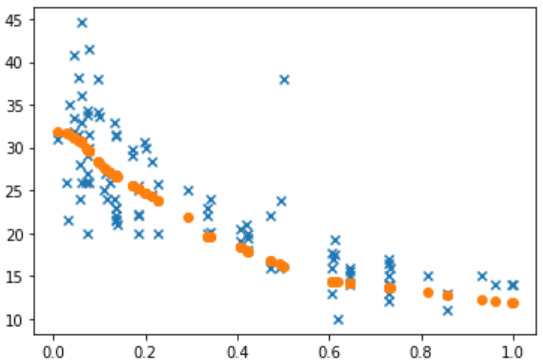

**Figura orientativa:** la imagen incrustada corresponde a un ejemplo anterior. No debe reproducir sus valores exactos; genere su gráfico con las particiones y la característica elegida en su propia ejecución.


## 8. Preguntas

Investigue los siguientes términos del conocimiento automotriz:

- Displacement
- Weight
- Horsepower
- Cylinders
- Model Year
- Origin
- Acceleration

Investige la razón o justificación de la tendencia que muestra el gráfico obtenido en el paso anterior.

 - Que tendencia muestra el gráfico anterior.

 - Es la característica seleccionada la única variable que afecta el rendimiento en el consumo de combustible en los automóviles?

 - Hay otra relación o interacción con alguna característica que pueda ayudar a explicar el consumo de combustibles?